In [1]:
#Carga de datos
import pandas as pd
import json
import numpy as np
from Server_PD import download_dataframe_minio

from collections import Counter
import re

#Graficas
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

from itertools import combinations
import ast

import analisisutils as utils


# Carga de datos

In [2]:
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260309",claves=claves,file_format="parquet")
df.tail()

,ID,Titulo,Descripcion,Visualizaciones,Tags,Duracion,Fecha_publicacion,Titulo_canal,Subtitulos,Generos,Subgeneros,Made for kids,Rango_edad
31350,KEFuMgNoULU,Unbelievable 2026 Heartland Sundance XLT Fifth...,This 2026 Heartland Sundance XLT 24ML is a Fif...,0,"5053337, RVUSA",PT1M34S,2026-03-09 11:42:06+00:00,RVUSA,Kind: captions Language: en This 2026 H Heartl...,Autos & Vehicles,"Lifestyle (sociology), Vehicle",False,Adult
31351,i3RcDc9j-B0,Bargain Loving Brits In The Sun Daytime | Seri...,WATCH Bargain Loving Brits In The Sun Daytime ...,1457,"Bargain Loving Brits In The Sun, Bargain lovin...",PT42M40S,2026-03-08 16:00:55+00:00,Bargain Loving Brits,None,Entertainment,"Lifestyle (sociology), Television program, Tou...",False,Adult
31352,WJTrZVq98RM,"Good Morning America Full Broadcast — Sunday, ...",U.S. and Israeli forces launch a new wave of s...,100891,"ABC, ABC NEWS, GOOD MORNING AMERICA, p_cmsid=2...",PT31M57S,2026-03-08 17:00:45+00:00,ABC News,Kind: captions Language: en &gt;&gt; GOOD MORN...,News & Politics,"Politics, Society, Television program",False,Adult
31353,PEQa7dttgPA,How to Use an Oxy Soak for Grounding Product Care,Proper care plays an important role in maintai...,3,"earthshieldgrounding, earthing, grounding, fab...",PT58S,2026-03-09 00:58:16+00:00,EarthShield Grounding,Kind: captions Language: en Today I just wante...,People & Blogs,None,False,Adult
31354,pXW8_W1DF4c,Daily Prayer: The Lord Executes Justice for th...,"""The Lord executes justice for the oppressed a...",9,"Psalm 103:6-8, Prayer, daily prayer, Christian...",PT11M11S,2026-03-08 22:30:19+00:00,Light of Life,Kind: captions Language: en Daily Prayer The L...,Science & Technology,"Religion, Society",False,Adult


# Transformamos y añadimos columnas

In [3]:
#Duracion
def iso_a_minutos(iso_duration):
    """"
    Funcion que convierte la duracion a minutos
    """
    try:
        duracion = isodate.parse_duration(iso_duration)
        return duracion.total_seconds() / 60
    except:
        return 0

df['Duracion'] = df['Duracion'].apply(iso_a_minutos)

In [4]:
#Densidad de habla
df['Palabras_Por_Minuto'] = df.apply(utils.calcular_wpm, axis=1)
df['Palabras_Por_Minuto'] = round(df['Palabras_Por_Minuto'], 2)

# Limpiamos los datos

In [ ]:
#CREAR CODIGO LIMPIEZA GENEROS

# Creamos un diccionario con un df por cada genero

In [5]:
diccionario_generos = utils.division_generos(df)
for clave in diccionario_generos:
    print(clave, ":", len(diccionario_generos[clave]))
    df = diccionario_generos[clave]
    df_Adult, df_Kids = utils.division_edad(df)
    print(f'    Adultos: {len(df_Adult)}')
    print(f'    Kids: {len(df_Kids)}')
#Los 0 se deben a que youtube Kids y youtube Movies

Film & Animation : 2666
    Adultos: 634
    Kids: 2032
Autos & Vehicles : 340
    Adultos: 241
    Kids: 99
Music : 2632
    Adultos: 1108
    Kids: 1524
Pets & Animals : 489
    Adultos: 154
    Kids: 335
Sports : 1241
    Adultos: 298
    Kids: 943
Short Movies : 0
    Adultos: 0
    Kids: 0
Travel & Events : 429
    Adultos: 318
    Kids: 111
Gaming : 1610
    Adultos: 652
    Kids: 958
Videoblogging : 0
    Adultos: 0
    Kids: 0
People & Blogs : 3784
    Adultos: 2957
    Kids: 827
Comedy : 73
    Adultos: 48
    Kids: 25
Entertainment : 4470
    Adultos: 1328
    Kids: 3142
News & Politics : 3845
    Adultos: 3820
    Kids: 25
Howto & Style : 2049
    Adultos: 877
    Kids: 1172
Education : 6323
    Adultos: 1795
    Kids: 4528
Science & Technology : 1123
    Adultos: 778
    Kids: 345
Nonprofits & Activism : 281
    Adultos: 131
    Kids: 150
Movies : 0
    Adultos: 0
    Kids: 0
Anime/Animation : 0
    Adultos: 0
    Kids: 0
Action/Adventure : 0
    Adultos: 0
    Kids: 0
Clas

Vemos que hay muchos generos que no tienen ninguna aparicion. No los vamos a tener en cuenta para hacer las graficas.

In [ ]:
print("Cantidad de generos sin filtrar:", len(diccionario_generos))

diccionario_generos = dict(filter(lambda item: len(item[1]) > 0, diccionario_generos.items()))

print("Cantidad de generos filtrados:", len(diccionario_generos))


Cantidad de generos sin filtrar: 31
Cantidad de generos filtrados: 15


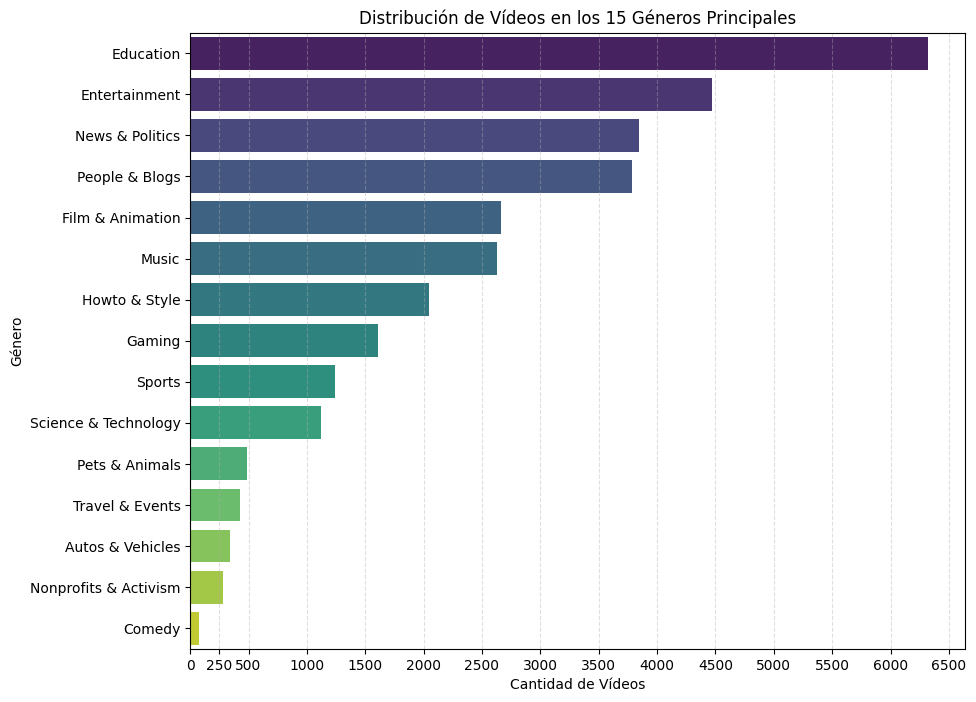

In [62]:
# 1. Extraemos los nombres de los géneros y la cantidad de vídeos de cada uno
generos_nombres = list(diccionario_generos.keys())
frecuencias = [len(df) for df in diccionario_generos.values()]

# Creamos una serie para ordenar de mayor a menor (como el top 20 original)
datos_ordenados = pd.Series(frecuencias, index=generos_nombres).sort_values(ascending=False)

# 2. Configuración de la gráfica
plt.figure(figsize=(10, 8))
sns.barplot(x=datos_ordenados.values, y=datos_ordenados.index, palette='viridis')

# 3. Lógica de Ticks (Adaptada de tu código original)
max_frecuencia = datos_ordenados.max()
tus_ticks = [0, 250, 500]

# Ajuste dinámico de pasos según el volumen de vídeos (ej. Society tiene >2000)
paso_automatico = 200 if max_frecuencia < 2000 else 500
ticks_automaticos = list(range(0, int(max_frecuencia) + paso_automatico, paso_automatico))

ticks_finales = sorted(list(set(tus_ticks + ticks_automaticos)))
plt.xticks(ticks_finales)

# 4. Detalles finales
plt.title("Distribución de Vídeos en los 15 Géneros Principales")
plt.xlabel("Cantidad de Vídeos")
plt.ylabel("Género")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

Nos quedamos con 15. De esos 15 vamos a trabajar con los 8 mas frecuentes.

In [13]:
claves_ordenadas = sorted(diccionario_generos, key=lambda k: len(diccionario_generos[k]), reverse=True)

generos_seleccionados = claves_ordenadas[:8]

diccionario_top = {k: diccionario_generos[k] for k in generos_seleccionados}

print(f"Top 8 generos mas frecuentes: {list(diccionario_top.keys())}")

Top 8 generos mas frecuentes: ['Education', 'Entertainment', 'News & Politics', 'People & Blogs', 'Film & Animation', 'Music', 'Howto & Style', 'Gaming']


Filtramos también los df en funcion a si tienen subtitulos o no

In [27]:
diccionario_subs = {
    clave: df[df['Subtitulos'].apply(lambda x: isinstance(x, str) and len(x.strip()) > 0)].copy() 
    for clave, df in diccionario_top.items()
}

for clave in diccionario_subs:
    print(f"{clave}: {len(diccionario_subs[clave])} vídeos con subtítulos.")

Education: 6323 vídeos con subtítulos.
Entertainment: 4470 vídeos con subtítulos.
News & Politics: 3845 vídeos con subtítulos.
People & Blogs: 3784 vídeos con subtítulos.
Film & Animation: 2666 vídeos con subtítulos.
Music: 2632 vídeos con subtítulos.
Howto & Style: 2049 vídeos con subtítulos.
Gaming: 1610 vídeos con subtítulos.


# **Análisis no textual**

# Duracion

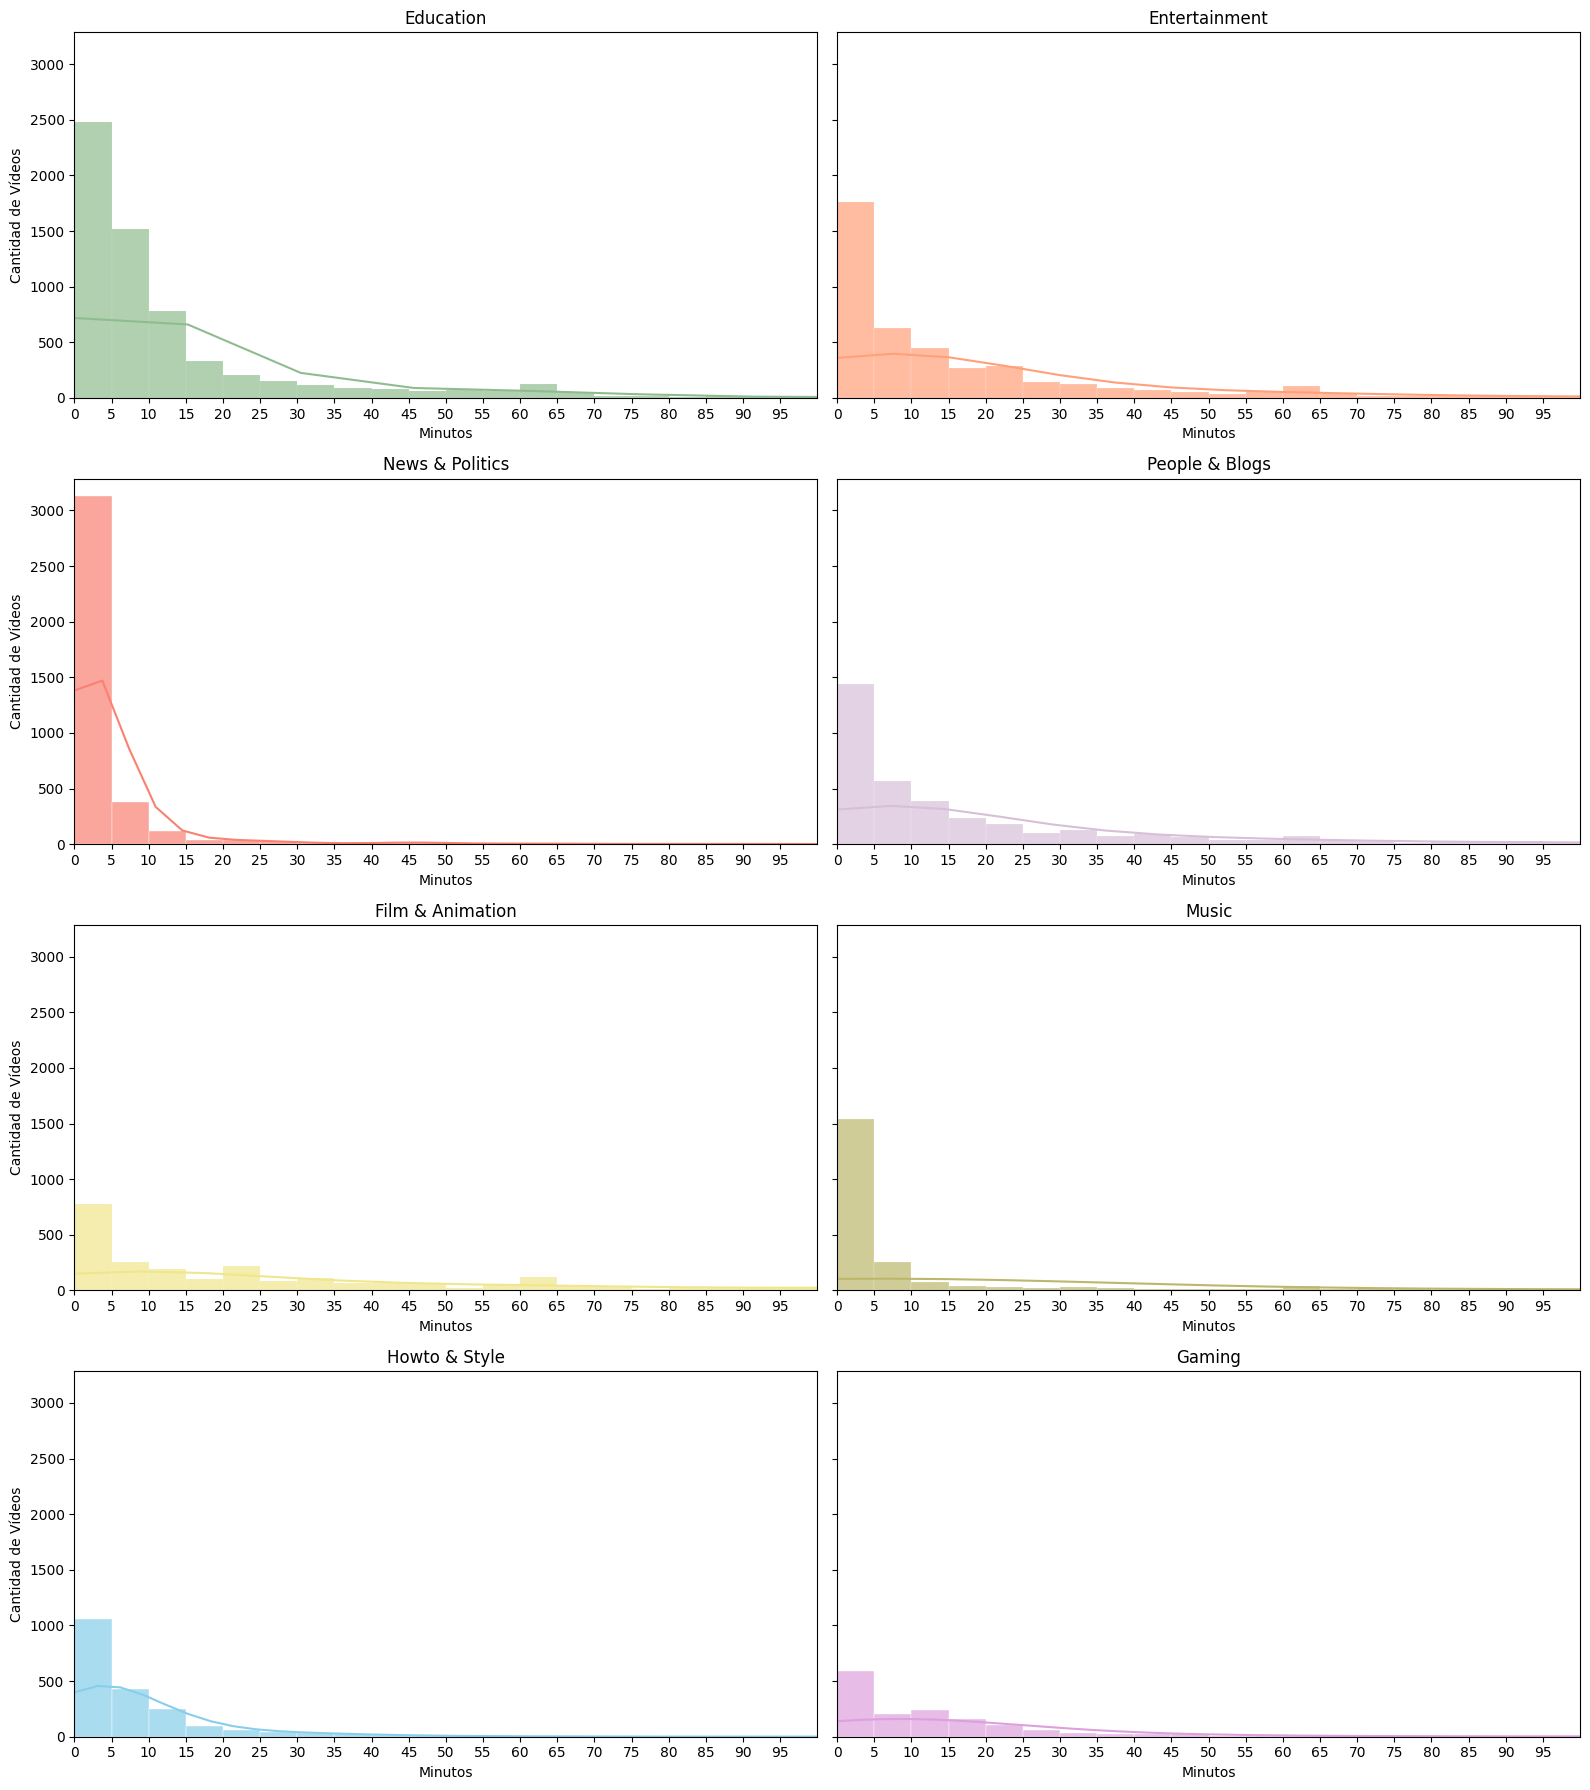

In [22]:
# Configuración
fig, ax = plt.subplots(4, 2, figsize=(16, 18), sharey=True)

ax = ax.flatten()
colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki', 'skyblue', 'plum']

for i, clave in zip(range(0,8), diccionario_top):
    utils.graficar_histograma_duracion(diccionario_top[clave], clave, ax[i], colores[i])

plt.tight_layout()
plt.show()

**COMPLETAR**

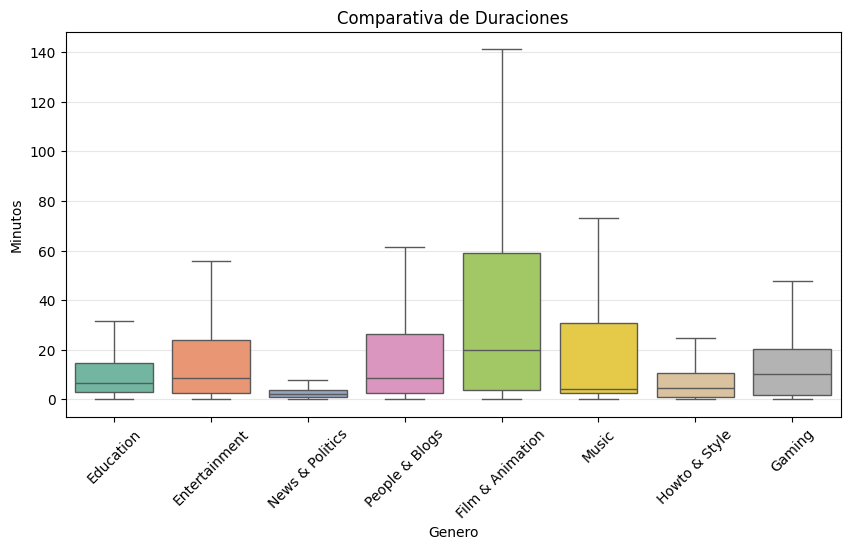

In [58]:
df_grafica = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_top8.items()
])

plt.figure(figsize=(10, 5))
sns.boxplot(x='Genero', y='Duracion', data=df_grafica, palette='Set2', showfliers=False)  

plt.xticks(rotation=45)
plt.title('Comparativa de Duraciones')
plt.ylabel('Minutos')
plt.grid(axis = "y", alpha = 0.3)
plt.show()

# Densidad de habla

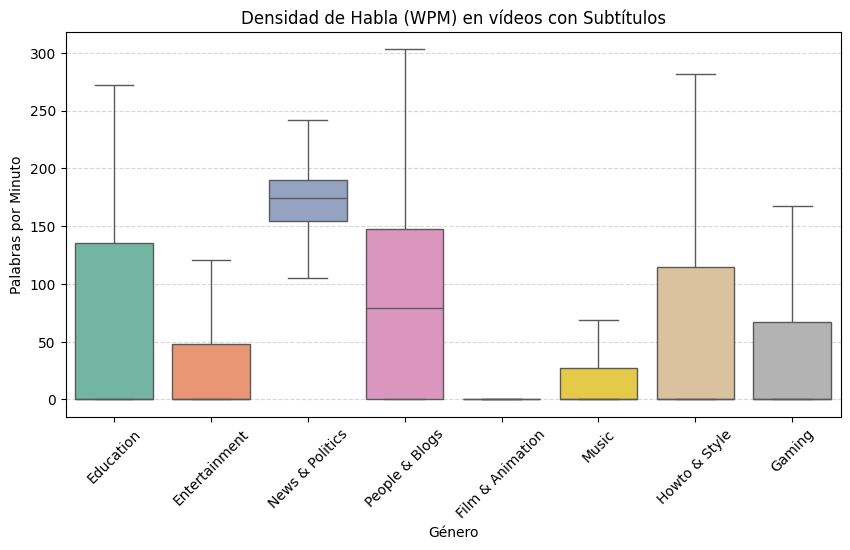

In [ ]:
df_grafica_subs = pd.concat([
    df.assign(Genero=clave) for clave, df in diccionario_subs.items()
])

plt.figure(figsize=(10, 5))

#No mostramos los outliers para que se vea más limpio
sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_grafica_subs, palette='Set2', showfliers=False)


plt.title('Densidad de Habla (WPM) en vídeos con Subtítulos')
plt.xlabel('Género')
plt.ylabel('Palabras por Minuto')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# **Analisis Textual**